# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 765.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 50.9 MB/s eta 0:00:00


In [2]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [10]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [11]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    # Lowercase
    text = text.lower()

    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Remove punctuation tokens
    tokens = [t for t in tokens if t not in string.punctuation]

    # Filter out stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Lemmatize remaining tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Join back into a single cleaned string
    cleaned_text = " ".join(tokens)

    return cleaned_text



### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [15]:
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

In [13]:
cleaned_reviews

["mcdonald 's food ok service bad",
 'would recommend japanese restaurant anyone',
 'loved restaurant traveled thailand last summer',
 'menu loving wide variety option',
 "staff friendly helpful google 's employee restaurant",
 'ambiance bella italia amazing pasta dish delicious',
 'terrible experience pizza hut pizza burnt service slow',
 'sushi sushi express always fresh flavorful',
 'steakhouse main street cozy atmosphere excellent steak',
 'dessert selection sweet treat die']

In [16]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions
#cleaned_reviews = None

if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [20]:
import spacy

# Load the small English model
nlp = spacy.load("en_core_web_sm")

def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # TODO: run the spaCy pipeline on the text
    # TODO: collect each entity text and its label_
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities



### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [21]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # TODO: tokenize the text
    tokens = word_tokenize(text)
    # TODO: call nltk.pos_tag on the tokens
    tagged_tokens = pos_tag(tokens)
    return tagged_tokens



### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [22]:
sample_texts = raw_reviews[:2]

print("NER on raw text")
for text in sample_texts:
    print(f"Text: {text}")
    print("Entities:", perform_ner(text))
    print()

print("\nNER on cleaned text")
for text in cleaned_reviews[:2]:
    print(f"Text: {text}")
    print("Entities:", perform_ner(text))
    print()

print("\nPOS tags on raw text")
for text in sample_texts:
    print(f"Text: {text}")
    print("POS:", perform_pos_tagging(text))
    print()

print("\nPOS tags on cleaned text")
for text in cleaned_reviews[:2]:
    print(f"Text: {text}")
    print("POS:", perform_pos_tagging(text))
    print()


NER on raw text
Text: At McDonald's the food was ok and the service was bad.
Entities: [('McDonald', 'ORG')]

Text: I would not recommend this Japanese restaurant to anyone.
Entities: [('Japanese', 'NORP')]


NER on cleaned text
Text: mcdonald 's food ok service bad
Entities: [("mcdonald 's food ok service", 'ORG')]

Text: would recommend japanese restaurant anyone
Entities: [('japanese', 'NORP')]


POS tags on raw text
Text: At McDonald's the food was ok and the service was bad.
POS: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]

Text: I would not recommend this Japanese restaurant to anyone.
POS: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]


POS tags on cleaned text
Text: mcdonald 's food ok service bad
P

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [23]:
from gensim.models import Word2Vec

# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]

# Train the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,   # dimensionality of word vectors
    window=5,          # context window size
    sg=1,              # 1 = skip-gram; 0 = CBOW
    min_count=2,       # ignore words with total frequency lower than this
    workers=4,         # number of worker threads
    epochs=10          # number of training iterations
)

# Inspect the model
w2v_model

### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [24]:
# TODO: print the vector size and vocabulary size of your model
# Vector size (embedding dimensionality)
print("Vector size:", w2v_model.vector_size)

# Vocabulary size (number of unique tokens learned)
print("Vocabulary size:", len(w2v_model.wv))

Vector size: 100
Vocabulary size: 5


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

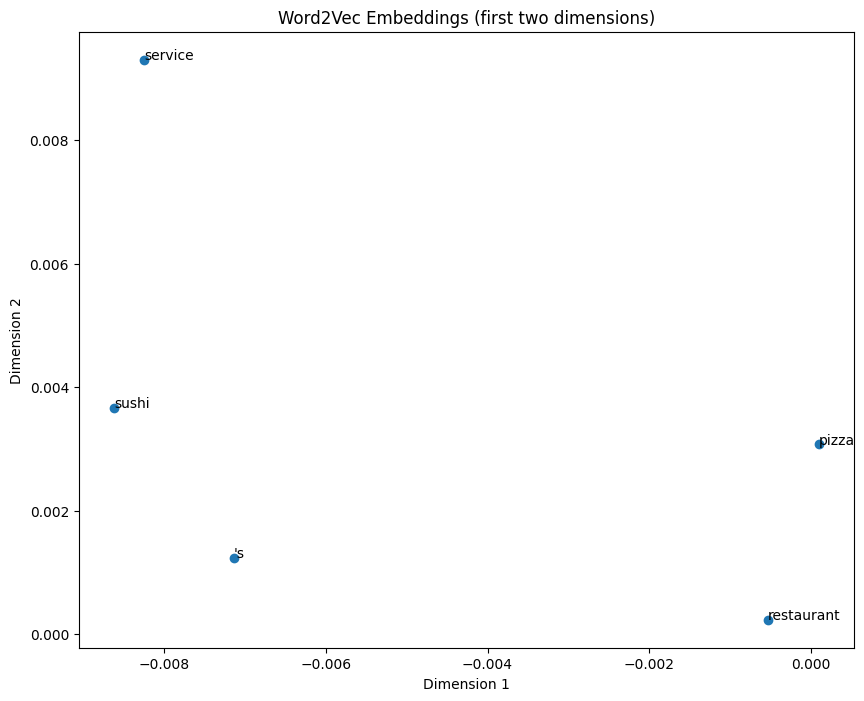

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model, words=None):
    """Scatter-plot the first two dimensions of word embeddings."""
    # If no specific words are passed, use the whole vocabulary (may be large!)
    if words is None:
        words = list(model.wv.index_to_key)[:50]  # limit to first 50 for readability

    # Get vectors for the selected words
    vectors = np.array([model.wv[w] for w in words])

    # Take the first two dimensions
    x = vectors[:, 0]
    y = vectors[:, 1]

    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(x, y)

    # Annotate each point with its word
    for i, word in enumerate(words):
        plt.annotate(word, (x[i], y[i]))

    plt.title("Word2Vec Embeddings (first two dimensions)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

# Call the plotting function using your trained model
plot_word_embeddings(w2v_model)


### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

In [26]:
from sklearn.decomposition import PCA

def plot_word_embeddings_pca(model, words=None):
    if words is None:
        words = list(model.wv.index_to_key)[:50]
    vectors = np.array([model.wv[w] for w in words])

    # Reduce to 2D
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(reduced[:, 0], reduced[:, 1])
    for i, word in enumerate(words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]))
    plt.title("Word2Vec Embeddings (PCA projection)")
    plt.show()

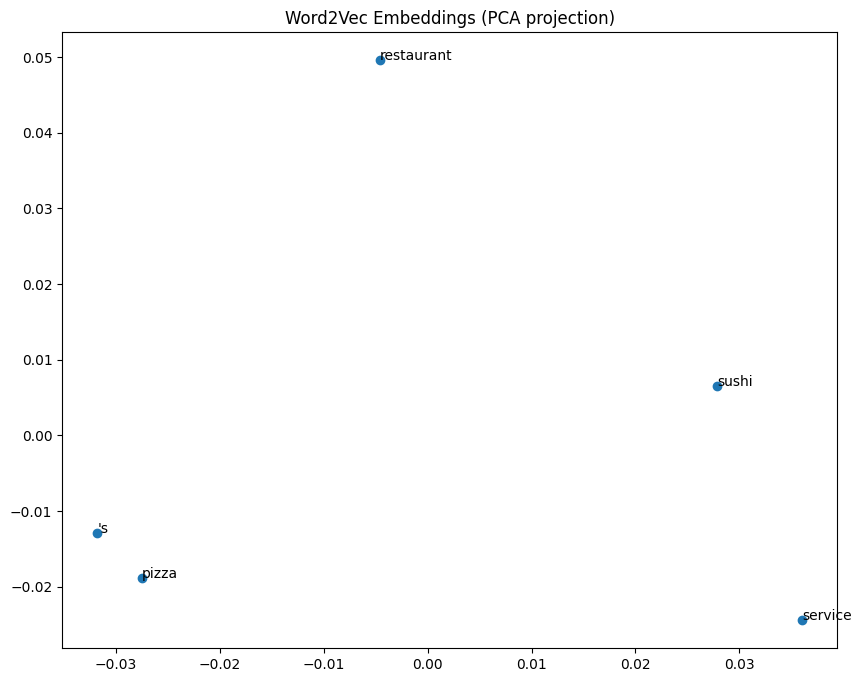

In [27]:
plot_word_embeddings_pca(w2v_model)
